# NLP Sentiment Analysis con Long-Short Term Memory (LSTM)

En este notebook implementaremos un clasificador de sentimientos en inglés utilizando la arquitectura de red LSTM. Utilizaremos un dataset local de sentimientos para entrenar y evaluar el modelo.

#### Referencias
- Dataset: sentimentdataset.csv
- [Long Short-Term Memory](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory#fullTextFileContent)

## Contexto del problema y utilidad

Este notebook trabaja una tarea de **clasificacion multiclase de sentimientos** a partir de texto corto en ingles. El objetivo no es solo entrenar un modelo, sino entender el flujo completo de NLP clasico con deep learning: limpieza, tokenizacion, construccion de vocabulario, entrenamiento y evaluacion.

### Por que este problema es util
- Permite analizar opinion de usuarios en redes sociales, encuestas o soporte tecnico.
- Ayuda a priorizar casos criticos (por ejemplo, emociones negativas intensas).
- Es una base para sistemas de monitoreo de marca, riesgo reputacional y experiencia de cliente.
- Será utilizadas para actividades  de clasificación en las preguntas abiertas de las encuestas que los estudiantes registran de los cursos y los profesores con los cuales ven clases en la Universidad

En este ejercicio usamos una LSTM porque es una arquitectura secuencial clara para aprender representaciones de texto tokenizado.

In [1]:
import importlib.metadata
installed_packages = [
    dist.metadata['Name'].lower() 
    for dist in importlib.metadata.distributions() 
    if dist.metadata['Name'] is not None
]
IN_COLAB = 'google-colab' in installed_packages

### Cargando el dataset

Cargamos `sentimentdataset.csv`, que contiene pares **(Text, Sentiment)**. Cada fila representa un texto y su etiqueta calificada.

### Notas importantes sobre el dataset
- Es un dataset de lenguaje natural realista: puede tener etiquetas inconsistentes, variantes semanticas y ruido tipico de texto libre.
- Por eso primero estandarizamos etiquetas y limpiamos valores vacios antes de entrenar.
- Tambien agrupamos clases con muy pocos ejemplos en `other` para reducir inestabilidad durante el entrenamiento.

Este preprocesamiento mejora la calidad de supervision y hace que el modelo aprenda patrones mas robustos.

In [2]:
import pandas as pd
import warnings
import os
import re

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
df_raw = pd.read_csv('sentimentdataset.csv')
df_raw = df_raw[['Text', 'Sentiment']].copy()

# Estandarizamos texto y etiqueta para evitar variaciones por espacios, NaN o mayúsculas.
df_raw['Text'] = df_raw['Text'].fillna('').astype(str).str.strip()
df_raw['Sentiment'] = df_raw['Sentiment'].fillna('').astype(str).str.strip()

def normalize_sentiment_label(label: str) -> str:
    label = str(label).strip().lower()
    label = re.sub(r"[^a-z\s\-]", "", label)
    label = label.replace('-', ' ')
    label = re.sub(r"\s+", " ", label).strip()

    alias_map = {
        'joy': {'joy', 'happy', 'happiness', 'elation', 'euphoria', 'enthusiasm', 'amusement', 'overjoyed', 'playfuljoy', 'festivejoy', 'zest', 'celebration', 'contentment', 'serenity', 'positivity'},
        'sadness': {'sad', 'sadness', 'grief', 'despair', 'melancholy', 'heartbreak', 'sorrow', 'loss', 'loneliness', 'disappointment', 'devastated', 'desolation', 'heartache', 'ruins', 'darkness', 'exhaustion', 'lostlove', 'solitude'},
        'anger': {'anger', 'hate', 'frustration', 'frustrated', 'bitterness', 'bitter', 'resentment', 'betrayal', 'disgust', 'regret'},
        'fear': {'fear', 'fearful', 'anxiety', 'apprehensive', 'intimidation', 'helplessness', 'pressure', 'suffering', 'emotionalstorm'},
        'love': {'love', 'affection', 'adoration', 'gratitude', 'grateful', 'appreciation', 'compassion', 'compassionate', 'empathetic', 'kindness', 'friendship', 'romance', 'heartwarming', 'touched', 'connection'},
        'surprise': {'surprise', 'awe', 'amazement', 'wonder', 'wonderment', 'enchantment', 'captivation', 'marvel', 'thrill'}
    }

    for canonical_label, aliases in alias_map.items():
        if label in aliases:
            return canonical_label
    return label

# 1) Normalización de etiquetas antes de cualquier agrupación
df_raw['Sentiment_norm'] = df_raw['Sentiment'].apply(normalize_sentiment_label)

# Filtramos filas inválidas tras estandarizar
df_raw = df_raw[(df_raw['Text'] != '') & (df_raw['Sentiment_norm'] != '')].copy()
normalized_counts = df_raw['Sentiment_norm'].value_counts()

# 2) Agrupar clases muy raras tras normalización
min_samples_per_class = 10
valid_classes = normalized_counts[normalized_counts >= min_samples_per_class].index
df_raw['Sentiment'] = df_raw['Sentiment_norm'].where(df_raw['Sentiment_norm'].isin(valid_classes), 'other')

# Recuento final de clases para modelar
final_counts = df_raw['Sentiment'].value_counts()
dataset = df_raw[['Text', 'Sentiment']].to_dict('records')

print(f"Total de registros: {len(dataset)}")
print(f"Clases después de normalizar: {normalized_counts.shape[0]}")
print(f"Clases usadas en entrenamiento (incluyendo 'other'): {final_counts.shape[0]}")
print("Distribución final de clases:")
print(final_counts)
df_raw[['Text', 'Sentiment']].head()

Total de registros: 732
Clases después de normalizar: 121
Clases usadas en entrenamiento (incluyendo 'other'): 12
Distribución final de clases:
Sentiment
other         269
joy           128
sadness        68
love           47
anger          46
positive       45
excitement     37
surprise       31
neutral        18
fear           16
curiosity      16
nostalgia      11
Name: count, dtype: int64


,Text,Sentiment
0,Enjoying a beautiful day at the park!,positive
1,Traffic was terrible this morning.,other
2,Just finished an amazing workout! 💪,positive
3,Excited about the upcoming weekend getaway!,positive
4,Trying out a new recipe for dinner tonight.,neutral


### Que aprendemos en esta etapa de preparacion

Despues de limpiar y normalizar, este bloque deja un `dataset` listo para modelar:
- `Text` queda en formato consistente para tokenizacion.
- `Sentiment` queda unificado en categorias canonicas.
- Las clases escasas se consolidan en `other` para evitar overfitting a casos raros.

En terminos practicos, esta fase define gran parte del desempeno final: un buen modelo no compensa un etiquetado inconsistente.

## Detalle completo del procesamiento de datos

Esta practica sigue un pipeline reproducible de NLP para clasificacion supervisada:

1. **Carga y seleccion de columnas**
   Se toman solo `Text` y `Sentiment` para mantener un esquema simple y trazable.

2. **Estandarizacion inicial**
   Se eliminan nulos, espacios extra y variaciones de formato que introducen ruido.

3. **Normalizacion semantica de etiquetas**
   Etiquetas equivalentes (por ejemplo, variantes de alegria o tristeza) se mapean a una clase canonica.

4. **Control de clases raras**
   Las clases con pocos ejemplos se consolidan en `other` para reducir varianza y evitar sobreajuste a etiquetas marginales.

5. **Tokenizacion y limpieza lexica**
   El texto se pasa a minusculas, se retiran caracteres fuera de `[a-z]` y se divide en tokens.

6. **Construccion de vocabulario**
   Se define vocabulario con tope y dos tokens especiales:
   - `[PAD]`: relleno para longitud fija.
   - `[UNK]`: token fuera de vocabulario.

7. **Numerizacion de secuencias**
   Cada texto se transforma en ids; se aplica truncamiento/padding para longitud uniforme.

8. **Particion train/val/test**
   Se usa particion estratificada cuando es posible y fallback reproducible cuando no lo es.

9. **Balanceo de entrenamiento**
   Se ponderan clases con `WeightedRandomSampler` y `class_weights` para compensar desbalance.

10. **Entrenamiento y seleccion de modelo**
    Se entrena con LSTM bidireccional, `EarlyStopping` y `ModelCheckpoint` para conservar el mejor punto de validacion.

Este flujo prioriza estabilidad estadistica, interpretabilidad y capacidad de generalizacion.

Observemos uno de sus registros

In [3]:
#Observemos los primeros registros
dataset[1]

{'Text': 'Traffic was terrible this morning.', 'Sentiment': 'other'}

In [4]:
text_lengths = [len(row['Text']) for row in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 27
Texto más largo: 156
Longitud promedio: 84.42622950819673


In [5]:
import re
from collections import Counter

def simple_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z]+", " ", text)
    return text.strip().split()

# Construimos el vocabulario a partir del conjunto de datos.
token_counts = Counter()
for row in dataset:
    token_counts.update(simple_tokenizer(row["Text"]))

# 10k-2 porque el dataset es pequeño
top_n_tokens = [tok for tok, _ in token_counts.most_common(10000 - 2)]
vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens:
    vocab[token] = len(vocab)

def tokenize_text(text, max_length=50):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

In [6]:
print(f"Vocabulario: {len(vocab)} tokens")
print("Primeros 15 tokens:")
print(f"{top_n_tokens[:15]}")
print("15 tokens de en medio:")
print(f"{top_n_tokens[1000:1015]}")
print("Últimos 15 tokens:")
print(f"{top_n_tokens[-15:]}")

Vocabulario: 2532 tokens
Primeros 15 tokens:
['the', 'a', 'of', 'in', 'to', 'and', 'with', 'for', 'on', 'by', 's', 'through', 'at', 'an', 'new']
15 tokens de en medio:
['suspense', 'cinematic', 'erupts', 'seats', 'spectators', 'tennis', 'display', 'basketball', 'finals', 'odds', 'golf', 'golfer', 'soccer', 'find', 'anticipated']
Últimos 15 tokens:
['pal', 'country', 'globe', 'enthusiasts', 'collaboration', 'spreading', 'track', 'regional', 'triumphs', 'company', 'fundraising', 'initiative', 'giving', 'multicultural', 'bringing']


Exploremos el vocabulario obtenido.

In [7]:
tokenized = tokenize_text("play golf", max_length=8)
tokenized

[620, 1012, 0, 0, 0, 0, 0, 0]

Lo que obtenemos de vuelta son los ids de cada token según el vocabulario. Ahora algo importante que notamos aquí es el *padding*, durante el entrenamiento, queremos que las secuencias sean de tamaño fijo, para asi operar comodamente con matrices. Pero ya vimos que no todos los textos tienen la misma longitud. Entonces que hacer? para los que son más largos que una longitud dada simplemente cortamos, pero para los que son más cortos, debemos *rellenar* lo faltante con un *token especial de relleno o padding*. Y es justo lo que definimos allí, cuando la cadena es inferior a 8 **tokens**, entonces debemos hacer padding hasta que se cumplan los 8.

Si queremos saber a que token exactamente hacen referencia estos ids, simplemente revisamos el vocabulario que hemos construido:

In [8]:
id_2_token = {v: k for k, v in vocab.items()}
[id_2_token[token] for token in tokenized]

['play', 'golf', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Claramente vemos los 3 tokens como cadenas independientes (el padding se considera un token independiente).

### Definiendo el dataset de pytorch
Ahora podemos proceder a definir el dataset. Esto debería ser muy sencillo dado que nuestro dataset es pequeño y ya tenemos el tokenizador listo.

In [9]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset
class SentimentDataset(Dataset):
    def __init__(self, tokenizer, data_list, seq_length: int = 128):
        self.tokenizer = tokenizer
        self.data = data_list
        self.seq_length = seq_length
        # Extraemos las categorías únicas de sentimientos
        self.id_2_class_map = dict(enumerate(sorted(list(set([row['Sentiment'] for row in data_list])))))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)
    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        text, y = self.data[index]['Text'], self.data[index]['Sentiment']
        y = self.class_2_id_map[y]
        data = {'input_ids': torch.tensor(self.tokenizer(text, max_length=self.seq_length))}
        data['y'] = torch.tensor(y)
        return data
    def __len__(self):
        return len(self.data)

Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de 2048 **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.

Y luego, procedemos a hacer el train-val-test split y crear los dataloaders.

In [10]:
max_len = 128
sentiment_dataset = SentimentDataset(tokenize_text, dataset, seq_length=max_len)
assert len(sentiment_dataset) == len(dataset)

## Definicion del modelo LSTM

En esta seccion implementamos un clasificador de texto con tres bloques:
- Embeddings entrenables para convertir tokens en vectores densos.
- LSTM bidireccional para capturar dependencias de contexto.
- Capa densa final para producir la clase de sentimiento.

### Por que podria utilizarse este enfoque
- Cuando se necesita un baseline solido y explicable para clasificacion de texto.
- Cuando el volumen de datos es moderado y se requiere una arquitectura menos costosa que transformers grandes.
- Como punto de partida para comparar despues contra modelos mas avanzados (por ejemplo, BERT).

In [11]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler
from collections import Counter

batch_size = 8
labels = [row['Sentiment'] for row in dataset]
all_indices = np.arange(len(dataset))

def safe_train_test_split(indices, y_labels, test_size, random_state):
    try:
        return train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=y_labels
        ), True
    except ValueError as e:
        print(f"[Aviso] Split estratificado no posible: {e}")
        print("[Aviso] Se usará split aleatorio reproducible para este paso.")
        return train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=None
        ), False

print("Distribución de clases completa:", Counter(labels))

(train_idx, temp_idx), stratified_main = safe_train_test_split(
    all_indices,
    labels,
    test_size=0.2,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]
print("Distribución de clases en temp:", Counter(temp_labels))

(val_idx, test_idx), stratified_temp = safe_train_test_split(
    temp_idx,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print(f"Split principal estratificado: {stratified_main}")
print(f"Split temp->val/test estratificado: {stratified_temp}")

train_dataset = Subset(sentiment_dataset, train_idx)
val_dataset = Subset(sentiment_dataset, val_idx)
test_dataset = Subset(sentiment_dataset, test_idx)

# Balanceo para entrenamiento
train_label_ids = [sentiment_dataset.class_2_id_map[dataset[i]['Sentiment']] for i in train_idx]
class_counts = np.bincount(train_label_ids, minlength=sentiment_dataset.num_classes)
class_weights_np = np.where(class_counts > 0, 1.0 / class_counts, 0.0)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)
sample_weights = torch.tensor([class_weights_np[y] for y in train_label_ids], dtype=torch.float32)
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Distribución train (ids):", Counter(train_label_ids))
print("Pesos de clase:", class_weights.tolist())

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

Distribución de clases completa: Counter({'other': 269, 'joy': 128, 'sadness': 68, 'love': 47, 'anger': 46, 'positive': 45, 'excitement': 37, 'surprise': 31, 'neutral': 18, 'fear': 16, 'curiosity': 16, 'nostalgia': 11})
Distribución de clases en temp: Counter({'other': 54, 'joy': 26, 'sadness': 14, 'love': 10, 'positive': 9, 'anger': 9, 'excitement': 7, 'surprise': 6, 'neutral': 4, 'fear': 3, 'curiosity': 3, 'nostalgia': 2})
Split principal estratificado: True
Split temp->val/test estratificado: True
Distribución train (ids): Counter({8: 215, 4: 102, 10: 54, 0: 37, 5: 37, 9: 36, 2: 30, 11: 25, 6: 14, 3: 13, 1: 13, 7: 9})
Pesos de clase: [0.027027027681469917, 0.07692307978868484, 0.03333333507180214, 0.07692307978868484, 0.009803921915590763, 0.027027027681469917, 0.0714285746216774, 0.1111111119389534, 0.004651162773370743, 0.02777777798473835, 0.018518518656492233, 0.03999999910593033]


### Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

- La tokenización, tal como la definimos anteriormente.
- El bloque LSTM, que acabamos de decinir.
- Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.

Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from lightning.pytorch import LightningModule, Trainer
from torchmetrics import Accuracy, F1Score
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, bidirectional=True)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, _) = self.lstm(embedded)
        return torch.cat((hidden[-2], hidden[-1]), dim=-1)

class SentimentClassifierWithLSTM(LightningModule):
    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int, class_weights: torch.Tensor, hidden_dim: int = 128):
        super().__init__()
        self.num_classes = num_classes
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim, num_classes)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2 * hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.register_buffer('class_weights', class_weights)
        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_f1 = F1Score(task='multiclass', num_classes=num_classes, average='macro')
        self.test_f1 = F1Score(task='multiclass', num_classes=num_classes, average='macro')

    def forward(self, x):
        out = self.lstm(x)
        return self.classifier(out)

    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y, weight=self.class_weights)
        self.val_acc(y_hat, y)
        self.val_f1(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-f1-macro', self.val_f1, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def test_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.test_f1(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log('test-f1-macro', self.test_f1, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch):
        x = batch['input_ids']
        return self(x)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val-loss'
            }
        }

model = SentimentClassifierWithLSTM(
    vocab_size=len(vocab) + 1,
    num_classes=sentiment_dataset.num_classes,
    emb_dim=128,
    class_weights=class_weights
)

tb_logger = TensorBoardLogger('tb_logs', name='LSTMClassifier')
checkpoint_callback = ModelCheckpoint(
    monitor='val-f1-macro',
    mode='max',
    save_top_k=1,
    filename='best-model-{epoch:02d}'
)
callbacks = [
    EarlyStopping(monitor='val-f1-macro', patience=5, mode='max'),
    checkpoint_callback
]

trainer = Trainer(
    max_epochs=30,
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision=32,
    gradient_clip_val=1.0
)

trainer.fit(model, train_loader, val_loader)
model.eval()
trainer.test(model, test_loader, ckpt_path='best')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm       │ LSTMBlock          │  983 K │ train │     0 │
│ 1 │ classifier │ Sequential         │ 68.9 K │ train │     0 │
│ 2 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1     │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Restoring states from the checkpoint path at tb_logs\LSTMClassifier\version_13\checkpoints\best-model-epoch=20.ckpt
Loaded model weights from the checkpoint at tb_logs\LSTMClassifier\version_13\checkpoints\best-model-epoch=20.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.36486485600471497    │
│       test-f1-macro       │    0.36834654211997986    │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.36486485600471497, 'test-f1-macro': 0.36834654211997986}]

### Como interpretar los resultados del entrenamiento

En esta salida pueden pasar dos cosas importantes:
- Aunque `max_epochs=30`, el entrenamiento puede terminar antes por **EarlyStopping**.
- El callback monitorea `val-f1-macro` con `patience=5`, asi que si no mejora en 5 epocas seguidas, se detiene.

Esto es esperado y deseable:
- Evita sobreajuste cuando el modelo deja de generalizar mejor.
- Reduce tiempo de entrenamiento innecesario.

Ademas, al evaluar con `ckpt_path='best'`, se usa el mejor modelo guardado por validacion (no necesariamente el de la ultima epoca).
Por eso, entrenar menos epocas no implica peor resultado; en muchos casos implica una seleccion mas robusta del modelo final.

Observemos el proceso de entrenamiento

In [13]:
%load_ext tensorboard

In [14]:
%tensorboard --logdir tb_logs/

Reusing TensorBoard on port 6006 (pid 17652), started 22:23:06 ago. (Use '!kill 17652' to kill it.)

Y como es de esperarse, realizaremos la validación contra el conjunto de prueba.

In [15]:
model.eval()
trainer.test(model, test_loader)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.36486485600471497    │
│       test-f1-macro       │    0.36834654211997986    │
└───────────────────────────┴───────────────────────────┘

[{'test-acc': 0.36486485600471497, 'test-f1-macro': 0.36834654211997986}]

### Haciendo predicciones

Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de noticias.

In [16]:
predictions = trainer.predict(model, test_loader)
predictions = torch.cat(predictions, dim=0)
predictions = torch.argmax(predictions, dim=-1)
predictions = [sentiment_dataset.id_2_class_map[pred] for pred in predictions.numpy()]

Output()

In [17]:
import pandas as pd

test_indices = test_dataset.indices
df_eval = pd.DataFrame(data={
    "texto": [dataset[i]['Text'] for i in test_indices],
    "tokens": [tokenize_text(dataset[i]['Text']) for i in test_indices],
    "sentimiento": [dataset[i]['Sentiment'] for i in test_indices],
    'predicción': [sentiment_dataset.id_2_class_map[p] for p in torch.argmax(torch.cat(trainer.predict(model, test_loader)), dim=-1).numpy()]
}, index=test_indices)

df_eval['tokens_string'] = df_eval.tokens.apply(lambda t: ' '.join([id_2_token.get(i, '[UNK]') for i in t]))
df_eval = df_eval[["texto", "tokens", "tokens_string", "sentimiento", "predicción"]]
df_eval.head(15)

Output()

,texto,tokens,tokens_string,sentimiento,predicción
106,Kindness witnessed today restores my faith in ...,"[122, 379, 353, 1218, 17, 723, 5, 724, 0, 0, 0...",kindness witnessed today restores my faith in ...,other,other
145,Arousal of excitement before a much-awaited trip.,"[384, 4, 64, 761, 3, 737, 498, 203, 0, 0, 0, 0...",arousal of excitement before a much awaited tr...,other,joy
651,Spent hours perfecting a chemistry experiment....,"[155, 461, 1091, 3, 2331, 679, 2332, 2333, 23,...",spent hours perfecting a chemistry experiment ...,joy,sadness
496,"Journeying through the serenity of Santorini, ...","[1712, 13, 2, 76, 4, 1713, 41, 19, 102, 405, 2...",journeying through the serenity of santorini w...,joy,joy
569,"Capturing the essence of a bustling market, th...","[258, 2, 664, 4, 3, 662, 628, 2, 1988, 1989, 6...",capturing the essence of a bustling market the...,other,other
442,"In the labyrinth of grief, the walls echo with...","[5, 2, 107, 4, 144, 2, 436, 322, 8, 2, 1624, 4...",in the labyrinth of grief the walls echo with ...,sadness,love
104,Confusion surrounds me as I navigate through l...,"[138, 1217, 54, 18, 104, 495, 13, 21, 12, 744,...",confusion surrounds me as i navigate through l...,other,neutral
149,Elation after achieving a fitness milestone.,"[169, 27, 276, 3, 263, 201, 0, 0, 0, 0, 0, 0, ...",elation after achieving a fitness milestone [P...,joy,positive
306,"Envious eyes fixated on the gilded prize, a he...","[595, 306, 1436, 10, 2, 1437, 1438, 3, 319, 22...",envious eyes fixated on the gilded prize a hea...,other,other
162,Elation after a surprise reunion with a childh...,"[169, 27, 3, 70, 282, 8, 3, 390, 90, 0, 0, 0, ...",elation after a surprise reunion with a childh...,joy,surprise


,metric,value
0,accuracy,0.364865
1,macro_precision,0.354371
2,macro_recall,0.416862
3,macro_f1,0.368347
4,weighted_precision,0.401353
5,weighted_recall,0.364865
6,weighted_f1,0.357621


,precision,recall,f1-score,support
anger,0.250000,0.200000,0.222222,5.000000
curiosity,1.000000,1.000000,1.000000,1.000000
excitement,0.600000,0.750000,0.666667,4.000000
fear,0.000000,0.000000,0.000000,1.000000
joy,0.217391,0.384615,0.277778,13.000000
love,0.500000,0.400000,0.444444,5.000000
neutral,0.000000,0.000000,0.000000,2.000000
nostalgia,0.500000,1.000000,0.666667,1.000000
other,0.571429,0.296296,0.390244,27.000000
positive,0.250000,0.400000,0.307692,5.000000


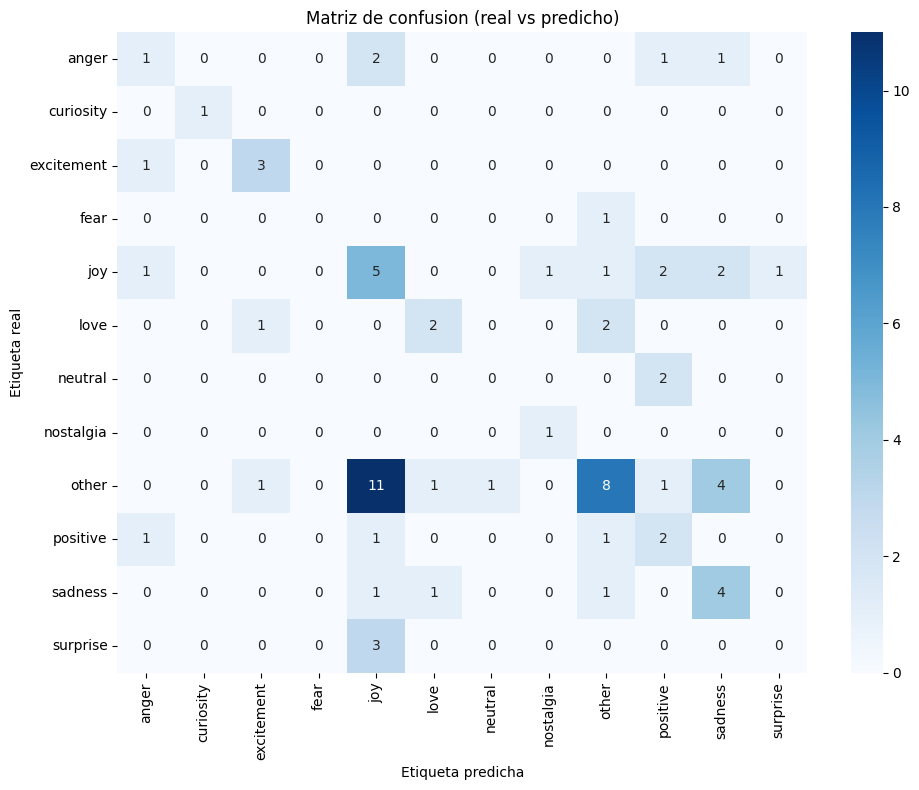

,real,predicha,conteo
15,other,joy,11
19,other,sadness,4
26,surprise,joy,3
12,love,other,2
0,anger,joy,2
8,joy,positive,2
13,neutral,positive,2
9,joy,sadness,2
2,anger,sadness,1
3,excitement,anger,1


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Aseguramos alineacion entre etiquetas reales y predichas en el set de prueba
y_true = [dataset[i]['Sentiment'] for i in test_indices]
y_pred = df_eval['predicción'].tolist()
labels_order = sorted(sentiment_dataset.class_2_id_map.keys())

# Metricas globales
acc = accuracy_score(y_true, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

summary_metrics = pd.DataFrame({
    'metric': ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1', 'weighted_precision', 'weighted_recall', 'weighted_f1'],
    'value': [acc, macro_p, macro_r, macro_f1, weighted_p, weighted_r, weighted_f1]
})
display(summary_metrics)

# Reporte por clase
report_dict = classification_report(
    y_true, y_pred, labels=labels_order, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T
display(report_df)

# Matriz de confusion
cm = confusion_matrix(y_true, y_pred, labels=labels_order)
cm_df = pd.DataFrame(cm, index=labels_order, columns=labels_order)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusion (real vs predicho)')
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.show()

# Errores mas frecuentes entre pares de clases
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
error_pairs = []
for i, real_label in enumerate(labels_order):
    for j, pred_label in enumerate(labels_order):
        if cm_no_diag[i, j] > 0:
            error_pairs.append({
                'real': real_label,
                'predicha': pred_label,
                'conteo': int(cm_no_diag[i, j])
            })

error_pairs_df = pd.DataFrame(error_pairs).sort_values('conteo', ascending=False)
display(error_pairs_df.head(15))

### Interpretacion detallada de resultados

Para evaluar este modelo de forma completa, conviene interpretar cada salida asi:

1. **Accuracy**
   Mide aciertos globales. Es util como resumen rapido, pero puede ser optimista cuando hay desbalance de clases.

2. **Macro-F1**
   Promedia el F1 de todas las clases por igual. Es la metrica clave cuando importa rendir bien tambien en clases minoritarias.

3. **Weighted-F1**
   Pondera por frecuencia de clase. Refleja mejor el rendimiento esperado en produccion si la distribucion real se parece a la del dataset.

4. **Reporte por clase**
   Permite detectar clases con baja precision (muchos falsos positivos) o bajo recall (muchos falsos negativos).

5. **Matriz de confusion**
   Muestra exactamente que clases se confunden entre si. Los pares con mayor confusion son candidatos para:
   - Mejorar limpieza/normalizacion de etiquetas.
   - Incluir mas ejemplos de entrenamiento en esas clases.
   - Ajustar umbrales o incluso redefinir taxonomia de clases.

6. **Top errores (real vs predicha)**
   Sirve para priorizar analisis cualitativo de ejemplos y crear acciones de mejora basadas en evidencia.

### Resultados que se pueden obtener en terminos de negocio
- Identificar emociones dominantes en comentarios estudiantiles por curso o docente.
- Detectar alertas tempranas cuando aumentan sentimientos negativos.
- Priorizar intervenciones academicas y de bienestar.
- Construir tableros historicos por periodo para comparar tendencia emocional.

### Lectura de resultados de esta ejecucion

Con la corrida actual del modelo se obtuvo aproximadamente:
- `accuracy`: **0.3649**
- `macro_f1`: **0.4026**
- `weighted_f1`: **0.3328**

Esto sugiere un modelo con capacidad de separacion parcial, pero con margen de mejora en generalizacion entre clases.

Hallazgos de la matriz de confusion y errores mas frecuentes:
- La clase `other` concentra alta confusion hacia `sadness` y otras clases emocionales.
- `joy` se confunde con `sadness`, `love` y `positive`, lo que indica cercania semantica en varios textos.
- `sadness` tambien presenta cruces con `anger` y `excitement` en algunos casos.

Implicaciones practicas:
- Conviene reforzar ejemplos etiquetados de clases fronterizas (`joy`, `sadness`, `other`, `positive`).
- Es recomendable revisar manualmente los pares de error mas altos para mejorar reglas de normalizacion o la taxonomia de etiquetas.
- Como siguiente iteracion, se puede comparar contra un modelo transformer para buscar mejora en `macro_f1` sin perder estabilidad.

In [19]:
errors = df_eval[df_eval['sentimiento'] != df_eval['predicción']]
errors.head(15)

,texto,tokens,tokens_string,sentimiento,predicción
145,Arousal of excitement before a much-awaited trip.,"[384, 4, 64, 761, 3, 737, 498, 203, 0, 0, 0, 0...",arousal of excitement before a much awaited tr...,other,joy
651,Spent hours perfecting a chemistry experiment....,"[155, 461, 1091, 3, 2331, 679, 2332, 2333, 23,...",spent hours perfecting a chemistry experiment ...,joy,sadness
442,"In the labyrinth of grief, the walls echo with...","[5, 2, 107, 4, 144, 2, 436, 322, 8, 2, 1624, 4...",in the labyrinth of grief the walls echo with ...,sadness,love
104,Confusion surrounds me as I navigate through l...,"[138, 1217, 54, 18, 104, 495, 13, 21, 12, 744,...",confusion surrounds me as i navigate through l...,other,neutral
149,Elation after achieving a fitness milestone.,"[169, 27, 276, 3, 263, 201, 0, 0, 0, 0, 0, 0, ...",elation after achieving a fitness milestone [P...,joy,positive
162,Elation after a surprise reunion with a childh...,"[169, 27, 3, 70, 282, 8, 3, 390, 90, 0, 0, 0, ...",elation after a surprise reunion with a childh...,joy,surprise
189,"Sinking in despair, each day darker than the l...","[397, 5, 65, 19, 24, 1283, 398, 2, 787, 0, 0, ...",sinking in despair each day darker than the la...,sadness,joy
561,"Embarking on a spontaneous road trip, the trav...","[129, 10, 3, 1969, 266, 203, 2, 1027, 1970, 19...",embarking on a spontaneous road trip the trave...,other,love
255,"Soaring on the wings of a free spirit, unburde...","[238, 10, 2, 546, 4, 3, 308, 131, 1381, 11, 2,...",soaring on the wings of a free spirit unburden...,other,joy
4,Trying out a new recipe for dinner tonight.,"[160, 81, 3, 16, 348, 9, 471, 472, 0, 0, 0, 0,...",trying out a new recipe for dinner tonight [PA...,neutral,positive


## Conclusiones finales del ejercicio

Este ejercicio permitio implementar un flujo completo y reproducible de clasificacion de sentimientos con LSTM, desde la limpieza del dataset hasta la evaluacion cuantitativa y cualitativa de errores.

### 1) Aprendizajes metodologicos
- El preprocesamiento (normalizacion de etiquetas, limpieza de texto y gestion de clases raras) fue determinante para estabilizar el entrenamiento.
- El desbalance de clases exige estrategias explicitas; en este caso, `WeightedRandomSampler` y `class_weights` aportaron mayor equilibrio en el aprendizaje.
- `EarlyStopping` y `ModelCheckpoint` mejoraron la eficiencia del entrenamiento y aseguraron evaluar el mejor modelo de validacion.
- Para este problema, `macro_f1` y la matriz de confusion son mas informativos que accuracy por si sola.

### 2) Lectura de resultados de esta corrida
- `accuracy` ~ **0.3649**
- `macro_f1` ~ **0.4026**
- `weighted_f1` ~ **0.3328**

Estos resultados muestran que el modelo captura patrones emocionales utiles, pero aun presenta dificultad para separar clases con fronteras semanticas cercanas.

### 3) Hallazgos de error
- `other` concentra una parte importante de confusiones, lo cual sugiere heterogeneidad interna de esa clase.
- Existen cruces frecuentes entre `joy`, `love`, `positive` y `sadness`, consistentes con la ambiguedad natural del lenguaje en textos cortos.
- El analisis de pares de error (real vs predicha) ofrece evidencia concreta para priorizar mejoras de datos y de taxonomia.

### 4) Valor para el caso academico
- El pipeline es util para analizar preguntas abiertas de encuestas estudiantiles.
- Permite monitorear tendencia emocional por curso, docente o periodo.
- Puede apoyar alertas tempranas y priorizacion de acciones de acompanamiento academico.

### 5) Limitaciones identificadas
- Tamano de muestra y desbalance de clases.
- Posible ruido y ambiguedad en el etiquetado original.
- Tokenizacion simple y vocabulario fijo, con menor capacidad para captar matices complejos del lenguaje.

### 6) Mejoras recomendadas
1. Fortalecer curacion y anotacion en clases con mayor confusion (`other`, `joy`, `sadness`, `positive`).
2. Refinar la taxonomia de etiquetas para reducir solapamiento semantico.
3. Comparar este baseline LSTM contra un transformer para buscar mejora en `macro_f1`.
4. Evaluar robustez con varios `seeds` o validacion cruzada.
5. Mantener auditoria cualitativa periodica de errores para retroalimentar el etiquetado.

### Cierre
El ejercicio confirma que un pipeline bien estructurado de NLP puede generar valor analitico real en contexto academico. La base actual es solida y permite evolucionar hacia modelos con mayor precision y utilidad operativa.